# 확률보행 (Random Walk) </br>
*일부 사진의 저작권은 책에 귀속함*
- 프로세스가 정상적(staionary)인지 확인
    - 정상적: "시계열의 통계적 성질이 시간이 지나도 변하지 않는다"
    - 비정상적 프로세스일 경우, 차분(differencing)과 같은 변환 적용
- 자기상관함수 (autocorrelation function; ACF)를 도식화하여 주식의 일일 종가를 확률보행 모델로 근사화 (approximated)할 수 있는지 확인

정의: 무작위로 상승 또는 하락이 발생할 확률이 동일한 프로세스 
- 때로는 양의 추세, 때로는 음의 추세가 오래 지속되는 기간을 포함
- 급격한 방향 전환을 동반할 수 있음 </br>
현잿값 $y_t$는 이전 시간 다계의 값 $y_{t-1}$, 상수 $C$, 백색소음 (White Noise)라고 하는 난수 $\epsilon_t$의 함수
- $\epsilon_t$는 분산이 1, 평균이 0인 표준정규분포 </br></br>
**Equation: $y_t$ = $C$ + $y_{t-1}$ + $\epsilon_t$** </br>
상수 C $\neq$ 0 ==> 프로세스를 표류(drift)가 있는 확률보행이라고 함.

# 3.1.1 확률보행 프로세스 시뮬레이션하기

**일단 시작은 C가 0이라고 가정 </br>**
$y_t = y_{t-1} + \epsilon_t$ </br>
t = 0 시점에 초깃값 0으로 시작

$y_0 = 0$ </br>
$y_1 = y_0 + \epsilon = 0 + \epsilon_1 = \epsilon_1$ </br> </br>
**$y_2$로 표시하는 t=3의 값은 이전 단계의 값인 $y_2$에 약간의 백색소음을 더한 값 </br>**
$y_2 = \epsilon_1 + \epsilon_2$ </br>
$y_3 = y_2 + \epsilon_3 = \epsilon_1 + \epsilon_2 + \epsilon_3$ </br> </br>
$y_t$ = $\sum_{t=1}^{T} \epsilon_t$

![alt text](Screenshots/3/3.2.png)

## 무작위 프로세스 - random.seed

In [1]:
# 정규분포 (standard normal) 일 경우 백색소음의 정의에 맞춰 평균이 0, 분산이 1인 분포에서 숫자를 얻을 수 있음

import numpy as np
np.random.seed(42)

steps = np.random.standard_normal(1000) # 평균0, 분산1인 정규분포에서 1000개의 난수 생성
steps[0] = 0  # 수열의 첫 번째 값: 0

random_walk = np.cumsum(steps) # 시뮬 된 프로세스 내 각 시간 단계의 오차에 대한 누적 합계 계산

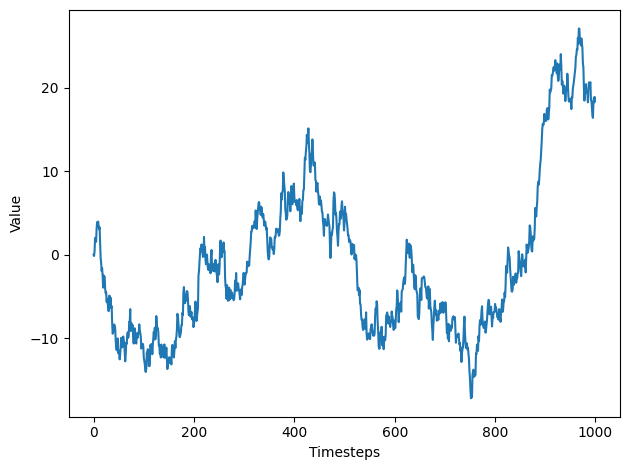

In [2]:
# 도식화
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(random_walk)
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')

plt.tight_layout()

* 해석: 처음 400개 시간 단계 동안 양의 추세 후 음의 추세; 끝으로 갈 수록 급격히 증가

* 하지만 실제 데이터에서는 시계열이 확률보행인지 아닌지 식별 필요

# 3.2 확률보행 식별 </br>
**확률보행**: 첫 번째 차분 (1st difference)이 정상적이고 상관관계는 없는 시계열; 절차가 완전히 무작위로 변화

![alt text](Screenshots/3/3.4.png)

## 3.2.1 정상성 Stationary </br>
정의: 시간이 지나도 통계적(평균, 분산, 자기상관관계) 특성이 변하지 않는 시계열
- 평균과 분산이 **상수** 이고 **자기상관관계**가 있으며, 이런 특성들이 시간에 따라 변하지 않는다. 

변환 (transform): 데이터를 수학적 조작을 통해 평균과 분산을 안정화해 정상적 상태로 만드는 것. 
- 차분: 평균 안정화, 추세 및 계절적 효과 제거 또는 줄일 수 있음 </br>

차분: 어떤 시간 단계와 그 다음 시간 단계 사이에 발생하는 일련의 변화를 계산
- $y'_{t} = y_{t} - y_{t-1}$ </br>

시계열에 로그 함수를 적용하면 *분산*을 안정시킬 수 있음.

![alt text](Screenshots/3/3.5.png)

변환 취소/역변환 (untransform/inverse transform): 변환된 시계열을 모델링할 때 모델의 출력을 원래 규모 (scale)로 되돌려야 함 </br>


## 3.2.2 정상성 테스트 </br>
시계열에 변환을 적용한 후 정상성 테스트를 수행하여 다른 변환을 더 적용해야 하는지 아니면 괜찮은지 확인해야 함.
* **ADF (Augmented Dickety Fuller)** 테스트: 시계열에 단위근 (unit root)이 존재하는 귀무가설 검증; 대체 가설은 단위근이 없으므로 시계열이 정상적이라는 가설
    - 결과값: 음수; 음수의 절대 크기가 클수록 귀무가설을 기각할 가능성이 크다
    - 파이썬에서는 p-값도 같이 나옴 (0.05보다 작으면 귀무가설 기각하여 수열이 정상적이라고 할 수 있음)

$y_t = C + \alpha_{1}y_{t-1} + \epsilon_{t}$ </br>
* $\alpha_1$ 은 unit circle 내에 있는 경우에만 정상적 (==> -1 < $\alpha_1$ < 1 ) 

![alt text](Screenshots/3/3.7.png)

정상적 수열: 시간에 무관하게 일정한 분산 = 시간에 독립적이라는 뜻</br>
비정상적 수열: 시간에 따라 변화하는 분산

시계열이 정상적이라면...
- 자기상관관계가 있는지 확인
    - 확률보행: 첫 번째 차분이 정상적이고 상관관계가 없는 수열
- ADF 테스트: 정상성 여부 확인하지만, 수열에 자기상관관계가 있는지를 확인하려면 자기상관함수를 사용해야 함

## 3.2.3 자기상관함수 (Autocorrelation Function; ACF)
</br>

* 상관관계: 두 변수 사이의 선형 관계를 측정한다.
    - 시계열의 선행값과 후행값 사이의 선형 관계 측정.

* 지연(lag; 두 값 사이의 시간 단계)이 증가함에 따라 두 값 사이의 상관관계가 어떻게 변하는지를 보여줌.
    - 지연 0의 자기상관관계의 계수: 언제나 1

ACF를 도식화할 시 짧은 지연에 대해서는 계수가 높고, 지연이 커짐에 따라 계수가 선형적으로 감소.

## 3.2.4 모든 것을 종합

In [3]:
# 확률보행을 식별하는데 필요한 절차

1) 확률보행이 정상적인가?
- 윗 그래프에서 눈에 보이는 추세가 있으므로 정상적이 아님.
- ADF 테스트를 적용해 확인

In [4]:
from statsmodels.tsa.stattools import adfuller

ADF_result = adfuller(random_walk)

print(f"ADF Stats: {ADF_result[0]}")
print(f"P-Value: {ADF_result[1]}")

ADF Stats: -0.9659524876918759
P-Value: 0.7654789696692579


해석: 
* ADF 통계는 크지 않은 음수
* p-val > 0.05 --> Fail to reject Null Hypothesis = 수열이 정상적이다라고 할 수 없음

이제는, 지연 횟수를 지정해 x-축의 범위를 결정. (여기서는 처음 20개의 지연을 도식화)

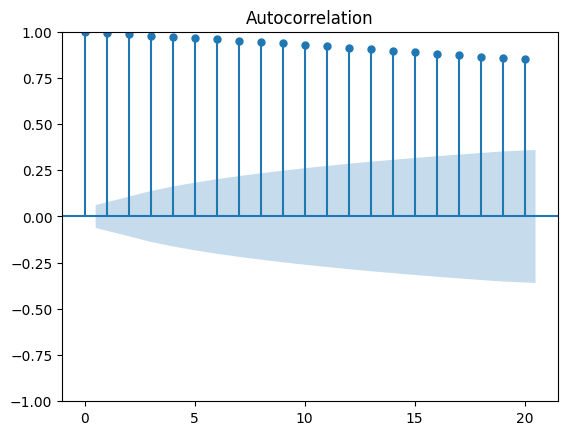

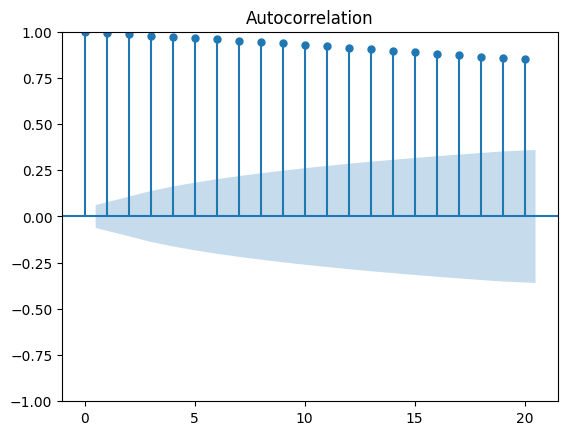

In [5]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(random_walk, lags = 20)

그림 해석:
- 자기상관계수가 서서히 감소. 지연 20에서도 여전히 자기상관관계가 있으므로, 확률보행이 비정상적.
- 음영 영역은 신뢰 구간 (confidence interval). 음영 영역 내에 있는 점은 0과 다르지 않음. 그렇지 않은 경우, 자기상관계수가 유의함.

유의미한 정보를 얻으려면 변환을 적용. 
- 1차 차분

**주의: 차분 적용시 첫 번째 데이터 요소가 손실**

In [6]:
diff_random_walk = np.diff(random_walk, n = 1)

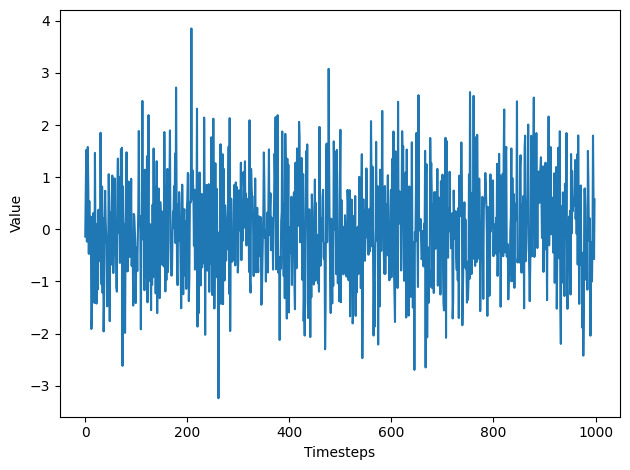

In [7]:
# 차분 된 확률보행의 전개.
# 수열에서 추세를 제거한 결과
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(diff_random_walk)
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')

plt.tight_layout()

분산은 상당히 안정적. ADF 테스트를 사용해 다시 한 번 정상성 테스트.

In [8]:
ADF_result = adfuller(diff_random_walk)

print(f"ADF Stats: {ADF_result[0]}")
print(f"P-Value: {ADF_result[1]}")

ADF Stats: -31.7893108575606
P-Value: 0.0


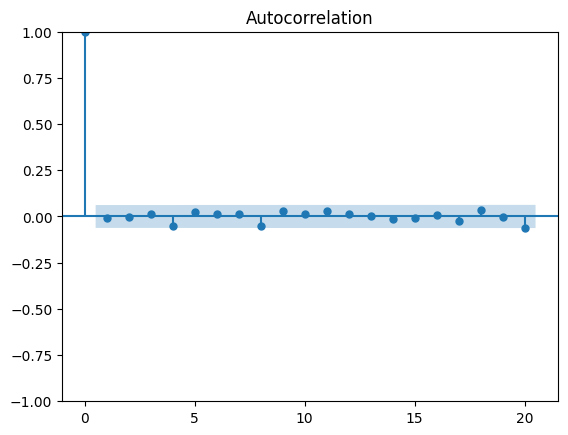

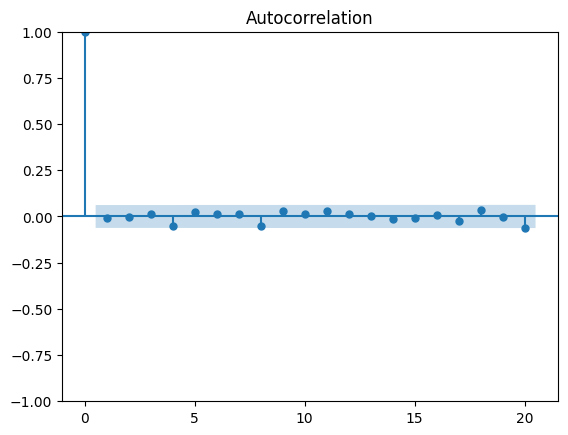

In [9]:
#정상적 수열의 ACF 함수를 도식화
plot_acf(diff_random_walk, lags = 20)

해석:
- 정상적 프로세스가 완전히 무작위 = 백색소음이라고 설명할 수 있음.

**각 값은 이전 값과 무작위로 차이를 보이며, 값들 사이에 아무런 관계가 없다.**

## 3.2.5 GOOGL은 확률보행인가?

Used the Marcopeix's GitHub Data Folder

In [10]:
import pandas as pd

url = 'https://raw.githubusercontent.com/marcopeix/TimeSeriesForecastingInPython/master/data/GOOGL.csv'
df = pd.read_csv(url)

df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2020-04-27,1292.000000,1294.099976,1265.060059,1270.859985,1270.859985,2209300
1,2020-04-28,1283.199951,1284.760010,1230.380005,1232.589966,1232.589966,4035000
2,2020-04-29,1345.000000,1360.150024,1326.729980,1342.180054,1342.180054,5417900
3,2020-04-30,1331.359985,1350.000000,1321.500000,1346.699951,1346.699951,2792100
4,2020-05-01,1324.089966,1351.430054,1309.660034,1317.319946,1317.319946,2443600
...,...,...,...,...,...,...,...
248,2021-04-21,2272.050049,2280.000000,2244.820068,2278.350098,2278.350098,1160200
249,2021-04-22,2275.399902,2288.879883,2240.320068,2252.520020,2252.520020,1207300
250,2021-04-23,2267.000000,2306.120117,2261.250000,2299.929932,2299.929932,1453300
251,2021-04-26,2304.520020,2324.530029,2297.320068,2309.929932,2309.929932,1595200


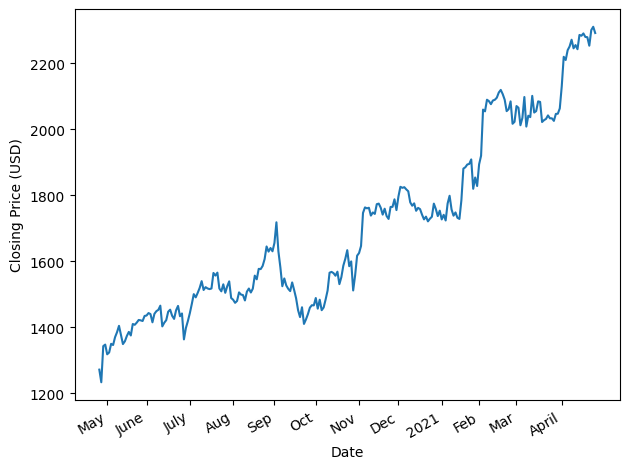

In [11]:
# 시각화

fig, ax = plt.subplots()

ax.plot(df["Date"], df["Close"])
ax.set_xlabel('Date')
ax.set_ylabel('Closing Price (USD)')

plt.xticks(
    [4, 24, 46, 68, 89, 110, 132, 152, 174, 193, 212, 235],
    ['May', 'June', 'July', "Aug", 'Sep', 'Oct', 'Nov', 'Dec', 2021, 'Feb', 'Mar', 'April']
)

fig.autofmt_xdate()
plt.tight_layout()

해석:
- 시간이 지남에 따라 종가가 상승하는 데이터의 추세 --> 정상적 프로세스가 아님.
- ADF 테스트를 통해 더욱 정확히 확인 가능

In [12]:
GOOGL_ADF_result = adfuller(df['Close'])
#왜 Close에만?
# --> Close열이 실제로 모델링/검토 대상인 시계열이다.
# --> 증가가 시간이 지남에 따라 추세를 가지는가?를 확인하기 위해 df["Close"]를 넣었음.

print(f'ADF Statistics: {GOOGL_ADF_result[0]}')
print(f'p-value: {GOOGL_ADF_result[1]}')

ADF Statistics: 0.1602504866477152
p-value: 0.9699419435913058


수치 역시 비정상적인 증명 </br>
그러므로 데이터를 차분한 뒤 차분된 데이터가 정상적인지 확인.

In [13]:
diff_close = np.diff(df['Close'], n=1)

GOOGL_diff_ADF_result = adfuller(diff_close)

print(f'ADF Statistics: {GOOGL_diff_ADF_result[0]}')
print(f'p-value: {GOOGL_diff_ADF_result[1]}')

ADF Statistics: -5.30343970429522
p-value: 5.386530961454919e-06


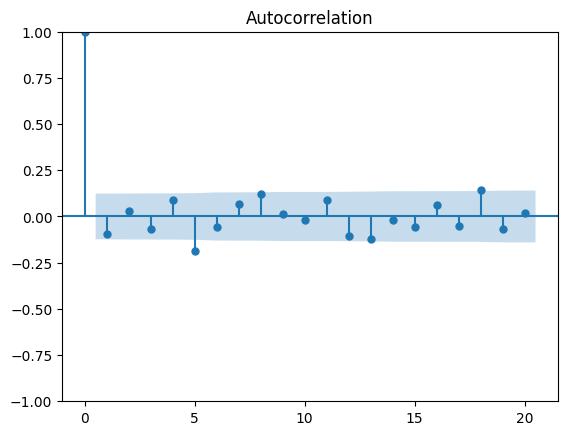

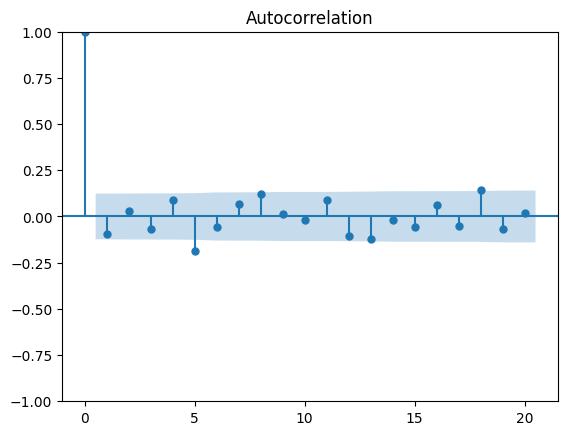

In [14]:
# 도식화하여 자기상관관계가 있는가?

from statsmodels.graphics.tsaplots import plot_acf

plot_acf(diff_close, lags = 20)

의문점: 지연5와 18을 제외하고는 유의한 계수가 없지 않는가?
- 우연임. </br>

연속적인 유의한 계수가 없으므로 지연 5와 18도 유의하지 않다고 보수적으로 가정. 일부 데이터에서 우연히 발생할 수 있고, 지연 0과 5, 또는 지연 0과 18 사이에 연속적으로 유의한 계수가 없으므로 이 지연은 유의하지 않다고 가정할 수 있음.

# 3.3 확률보행 예측

확률보행을 처리할 때는 다음 시간 단계만 예측하는 것이 이상적. 하지만 미래의 많은 시간 단계를 예측해야하는 경우도 생김. 각 상황에 대처하는 방법을 살펴봄.

## 3.3.1 긴 기간 예측

확률보행이 예기치 않게 증가하거나 감소할 수 있어 예측하기에 이상적이지 않음.

3.1.1에서 시뮬레이션된 확률보행으로 작업.

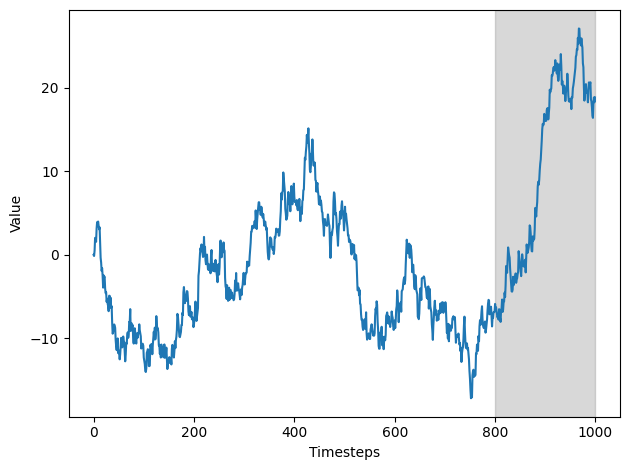

In [15]:
df = pd.DataFrame({'value': random_walk}) #시뮬된 확률보행을 df에 할당 후 value라는 열에 저장.

# 전체 시간 단계: 1000개
train = df[:800] #처음 80%가 훈련 집합. 
test = df[800:] # 나머지 20%는 테스트 집합.

#도식화
# 도식화
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(df)
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')
ax.axvspan(800, len(df) - 1, color='gray', alpha=0.3)

plt.tight_layout()

확률보행을 다루고 있는 상황에서는 단순한 예측 방법만 사용.

아래는 과거의 평균을 사용해 예측.
- 훈련 집합의 평균 계산
- 다음 200개의 시간 단계 동안 이 값과 같은 값일 것이라고 가정.

In [16]:
mean = np.mean(train.value)

test.loc[:, 'pred_mean'] = mean

test.head()

#과거의 평균: -3.68

/var/folders/3z/5gfy93qs7vz0g17fs_bg32xr0000gn/T/ipykernel_16426/719216992.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.loc[:, 'pred_mean'] = mean


,value,pred_mean
800,-5.876664,-3.677206
801,-6.392708,-3.677206
802,-6.296588,-3.677206
803,-6.758863,-3.677206
804,-7.193359,-3.677206


다른 베이스라인 모델: 훈련 데이터 집합에서 마지막으로 측정된 값으로 예측.
- train의 마지막 값을 추출한 뒤 그 값을 다음 200개 시간 단계에 대한 예측값으로 할당.

In [17]:
last_value = train.iloc[-1].value
test.loc[:, 'pred_last'] = last_value # 마지막 값을 다음 200개 시간 단계에 대한 예측값으로 pred_last열에 할당

test.head()
#pred_mean은 여기서 무시
# -6.81이라는 상수를 예측값으로 지정.

/var/folders/3z/5gfy93qs7vz0g17fs_bg32xr0000gn/T/ipykernel_16426/2616381009.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.loc[:, 'pred_last'] = last_value # 마지막 값을 다음 200개 시간 단계에 대한 예측값으로 pred_last열에 할당


,value,pred_mean,pred_last
800,-5.876664,-3.677206,-6.814947
801,-6.392708,-3.677206,-6.814947
802,-6.296588,-3.677206,-6.814947
803,-6.758863,-3.677206,-6.814947
804,-7.193359,-3.677206,-6.814947


**표류기법 (Drift Method)**: 마지막으로 측정된 값으로 예측하는 방법을 수정한 것.
- 시간의 흐름에 따른 값의 증가나 감소를 허용.
- 이후 값이 변하는 속도는 훈련 집합에서 볼 수 있는 속도와 같다. 
- 이를 위해 훈련 집합의 첫 번째 값과 마지막 값 사이의 기울기를 계산한 뒤, 이 기울기를 미래에 단순히 외삽(extrapolate) 한다.

공식: 확률보행의 마지막 값인 $y_f$와 초깃값인 $y_i$의 차이.

기울기 = $\Delta y / \Delta x$ = $\frac{y_f - y_i}{\text(시간 단계 획수)-1}$

윗 항목 기준, 시뮬레이션된 확률보행의 초깃값은 0이라는 걸 알았으니,

표류 = $\frac{-6.81 - 0 }{800 - 1}$ = -0.0085

In [18]:
deltaX = 800 - 1
deltaY = last_value - 0

drift = deltaY / deltaX
print(drift)

-0.008529346056640632


해석:
 - 시간이 지남에 따라 예측값이 서서히 감소한다. (negative여서; positive면 서서히 증가)

forecast = drift * timestep + $y_i$

우선 훈련 집합 이후의 200개의 시간 단계에 대해 예측. (800 - 1000)
- 시간 단계의 범위를 1씩 증가하도록.
- 이후, 각 시간 단계에 표류값을 곱하여 예측값을 구함.
- 마지막으로 이 값을 test의 pred_drfit 열에 할당.

In [19]:
x_vals = np.arange(801, 1001, 1)
#801 in arange = 800th in real obs

pred_drift = drift * x_vals # 각 시간 단계에 표류값을 곱해 각 시간 단계에 대한 예측값. ****각 시간 단계에 대한 예측값.****

test.loc[:, 'pred_drift'] = pred_drift

test.head()

/var/folders/3z/5gfy93qs7vz0g17fs_bg32xr0000gn/T/ipykernel_16426/4157546169.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.loc[:, 'pred_drift'] = pred_drift


,value,pred_mean,pred_last,pred_drift
800,-5.876664,-3.677206,-6.814947,-6.832006
801,-6.392708,-3.677206,-6.814947,-6.840536
802,-6.296588,-3.677206,-6.814947,-6.849065
803,-6.758863,-3.677206,-6.814947,-6.857594
804,-7.193359,-3.677206,-6.814947,-6.866124


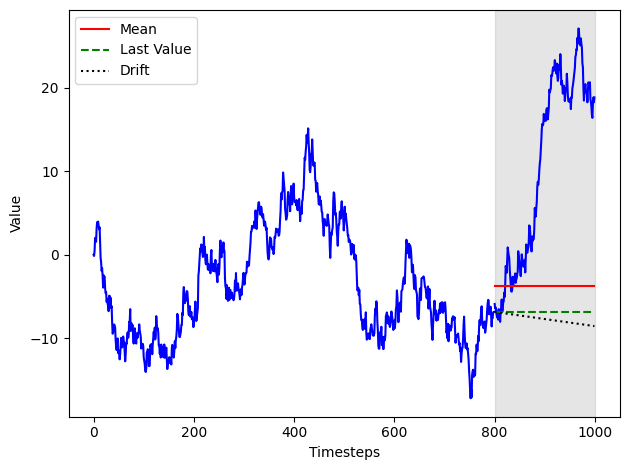

In [20]:
# 3가지 방법에 의한 예측값을 테스트 집합의 실젯값과 비교해 볼 수 있도록 시각화.

fig, ax = plt.subplots()

ax.plot(train.value, 'b-')
ax.plot(test['value'], 'b-')
ax.plot(test['pred_mean'], 'r-', label = 'Mean')
ax.plot(test['pred_last'], 'g--', label = 'Last Value')
ax.plot(test['pred_drift'], 'k:', label = 'Drift')

ax.axvspan(800, 1000, color = '#808080', alpha = 0.2)
ax.legend(loc = 2)

ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')

plt.tight_layout()

해석:
- 모든 예측이 상당히 성능이 떨어짐.
- 확률 보행에서는 미래의 변화가 완전히 무작위적이라 예측할 수 없으므로 당연한 결과.

평균제곱오차를 계산해보면 더욱 명확해짐.
- 다만, MAPE는 확률보행이 값이 0일 수 있기에 사용할 수 없음.

사용할 것: MSE

In [21]:
from sklearn.metrics import mean_squared_error

mse_mean = mean_squared_error(test['value'], test['pred_mean'])
mse_last = mean_squared_error(test['value'], test['pred_last'])
mse_drift = mean_squared_error(test['value'], test['pred_drift'])

print(mse_mean, mse_last, mse_drift)

326.50277395297474 425.1726033055617 466.2172769077409


해석:
- 과거의 평균 (mse_mean)으로 예측할 때 가장 좋은 예측 성능이나 그래도 300을 초과
    - 시뮬레이션 된 확률보행의 값이 30을 넘지 않는다는 점을 고려하면 매우 높은 값
- 긴 기간에 대해 확률보행을 예측하는 것이 유의하지 않다는 것을 알 수 있음.
    - 미랫값은 과것값과 무작위값을 더한 값이므로, 여러 번에 걸쳐 난수가 추가되는 긴 기간에 대해서는 무작위성이 더욱 커짐.


## 3.3.2 다음 시간 단계 예측하기

확률보행의 바로 다음 시간 단계를 예측하는 것이 제일 합리적인 방안.

구현법: 
- 초기 관측값을 사용해 다음 시간 단계를 예측하는 데 사용.
- 새로운 값을 기록하면 다음 시간 단계에 대한 예측으로 사용. 이 과정을 미래에도 반복.

![alt text](Screenshots/3/3.17.png)

In [22]:
df_shift = df.shift(periods = 1) #df_shit: 전체 확률 보행에 대한 예측; 각 시간 단계에서 마지막으로 측정된 값에 해당

df_shift.head()

,value
0,NaN
1,0.000000
2,-0.138264
3,0.509424
4,2.032454


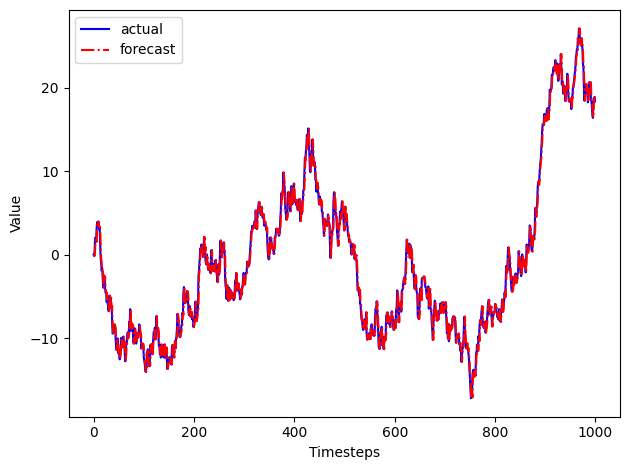

In [24]:
fig, ax = plt.subplots()

ax.plot(df, 'b-', label = 'actual')
ax.plot(df_shift, 'r-.', label = 'forecast')

ax.legend(loc = 2)

ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')

plt.tight_layout()

In [25]:
mse_one_step = mean_squared_error(test['value'], df_shift[800:])

print(mse_one_step)

0.9256876651440581


해석:
- MSE가 0에 가까우니 매우 우수한거 아닌가?
- 이전 시간 단계에서 확인된 값으로 예측하고 있을 뿐.

그래서, 확률보행 프로세스를 예측해야 하는 경우 *단기 예측을 여러번* 하는 편이 좋음. (난수가 누적되어 장기적으로 예측의 품질이 저하되는 것을 방지할 수 있음)

# 3.4 다음 단계

확률보행의 경우 예측을 할 수 있는 유일한 합리적 방법은 베이스라인 모델을 사용하는 것 </br>
미랫값이 무작위적으로 발생하는 데이터는 통계적 모델을 피팅하거나 딥러닝 기법 사용 불가. </br>
</br>
확률보행은 1차 차분한 결과에 자기상관관계가 없고, 정상적 프로세스로서, 평균, 분산, 자기상관관계가 시간이 흘러도 일정하다.

# 정리

확률보행 프로세스를 예측해야 할 경우, 단기 예측을 여러번 하는편이 좋음.

# 질문

확률보행 프로세스가 아니면, 그게 시사하는건 무엇인가?

ADF 통계값만 본다면:
- ADF Stats < Critical Value 라면, 귀무가설 기각